In [10]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import scanpy as sc
import anndata as ad

In [7]:
control_1_file_loc = "/Users/michael/Data/Soybean_data/Cell_ranger_output/cellranger_out_n_Cellbender_out_controls_C1_C1A_C2_control3_andrewgenome/RNA_leaf_C1_GEX/outs/filtered_feature_bc_matrix"
control_2_file_loc = "/Users/michael/Data/Soybean_data/Cell_ranger_output/cellranger_out_n_Cellbender_out_controls_C1_C1A_C2_control3_andrewgenome/RNA_leaf_C2_merged_GEX/outs/filtered_feature_bc_matrix"
control_3_file_loc = "/Users/michael/Data/Soybean_data/Cell_ranger_output/cellranger_out_n_Cellbender_out_controls_C1_C1A_C2_control3_andrewgenome/RNA_leaf_control_3_GEX/outs/filtered_feature_bc_matrix"
control_1a_file_loc = "/Users/michael/Data/Soybean_data/Cell_ranger_output/cellranger_out_n_Cellbender_out_controls_C1_C1A_C2_control3_andrewgenome/RNA_leaf_C1A_GEX/outs/filtered_feature_bc_matrix"

In [8]:
drought_1_file_loc = "/Users/michael/Data/Soybean_data/Cell_ranger_output/cellranger_out_n_Cellbender_out_drought_D1_D2_drought3_andrewgenome/RNA_leaf_D1_GEX_andrewgenome/outs/filtered_feature_bc_matrix"
drought_2_file_loc = "/Users/michael/Data/Soybean_data/Cell_ranger_output/cellranger_out_n_Cellbender_out_drought_D1_D2_drought3_andrewgenome/RNA_Leaf_D2_merged_GEX_andrewgenome/outs/filtered_feature_bc_matrix"
drought_3_file_loc = "/Users/michael/Data/Soybean_data/Cell_ranger_output/cellranger_out_n_Cellbender_out_drought_D1_D2_drought3_andrewgenome/RNA_leaf_drought_3_GEX_andrewgenome/outs/filtered_feature_bc_matrix"

heat_1_file_loc = "/Users/michael/Data/Soybean_data/Cell_ranger_output/cellranger_out_n_Cellbender_out_heat_H1_H2_heat3_andrewgenome_2/RNA_leaf_H1_GEX_andrewgenome/outs/filtered_feature_bc_matrix"
heat_2_file_loc = "/Users/michael/Data/Soybean_data/Cell_ranger_output/cellranger_out_n_Cellbender_out_heat_H1_H2_heat3_andrewgenome_2/RNA_leaf_H2_merged_GEX_andrewgenome/outs/filtered_feature_bc_matrix"
heat_3_file_loc = "/Users/michael/Data/Soybean_data/Cell_ranger_output/cellranger_out_n_Cellbender_out_heat_H1_H2_heat3_andrewgenome_2/RNA_leaf_heat_3_GEX_andrewgenome/outs/filtered_feature_bc_matrix"

HD_1_file_loc = "/Users/michael/Data/Soybean_data/Cell_ranger_output/cellranger_out_n_Cellbender_out_HD_HD1_HD2_HD3_andrewgenome/RNA_leaf_HD1_GEX_andrewgenome/outs/filtered_feature_bc_matrix"
HD_2_file_loc = "/Users/michael/Data/Soybean_data/Cell_ranger_output/cellranger_out_n_Cellbender_out_HD_HD1_HD2_HD3_andrewgenome/RNA_Leaf_HD2_merged_GEX_andrewgenome/outs/filtered_feature_bc_matrix"
HD_3_file_loc = "/Users/michael/Data/Soybean_data/Cell_ranger_output/cellranger_out_n_Cellbender_out_HD_HD1_HD2_HD3_andrewgenome/RNA_leaf_HD_3_GEX_andrewgenome/outs/filtered_feature_bc_matrix"

In [9]:
control_1 = sc.read_10x_mtx(control_1_file_loc, var_names="gene_symbols", cache=True)
control_2 = sc.read_10x_mtx(control_2_file_loc, var_names="gene_symbols", cache=True)
control_3 = sc.read_10x_mtx(control_3_file_loc, var_names="gene_symbols", cache=True)
control_1a = sc.read_10x_mtx(control_1a_file_loc, var_names="gene_symbols", cache=True)
heat_1 = sc.read_10x_mtx(heat_1_file_loc, var_names="gene_symbols", cache=True)
heat_2 = sc.read_10x_mtx(heat_2_file_loc, var_names="gene_symbols", cache=True)
heat_3 = sc.read_10x_mtx(heat_3_file_loc, var_names="gene_symbols", cache=True)
drought_1 = sc.read_10x_mtx(drought_1_file_loc, var_names="gene_symbols", cache=True)
drought_2 = sc.read_10x_mtx(drought_2_file_loc, var_names="gene_symbols", cache=True)
drought_3 = sc.read_10x_mtx(drought_3_file_loc, var_names="gene_symbols", cache=True)
HD_1 = sc.read_10x_mtx(HD_1_file_loc, var_names="gene_symbols", cache=True)
HD_2 = sc.read_10x_mtx(HD_2_file_loc, var_names="gene_symbols", cache=True)
HD_3 = sc.read_10x_mtx(HD_3_file_loc, var_names="gene_symbols", cache=True)

In [11]:
full_concatenated_adata = ad.concat(
    [
        control_1,
        control_2,
        control_3,
        control_1a,
        heat_1,
        heat_2,
        heat_3,
        drought_1,
        drought_2,
        drought_3,
        HD_1,
        HD_2,
        HD_3,
    ],
    join="outer",
    label="batch",
    keys=[
        "control_1",
        "control_2",
        "control_3",
        "control_1a",
        "heat_1",
        "heat_2",
        "heat_3",
        "drought_1",
        "drought_2",
        "drought_3",
        "HD_1",
        "HD_2",
        "HD_3",
    ],
    index_unique="-",
)

In [13]:
sc.pp.calculate_qc_metrics(
    full_concatenated_adata,
    inplace=True,
)

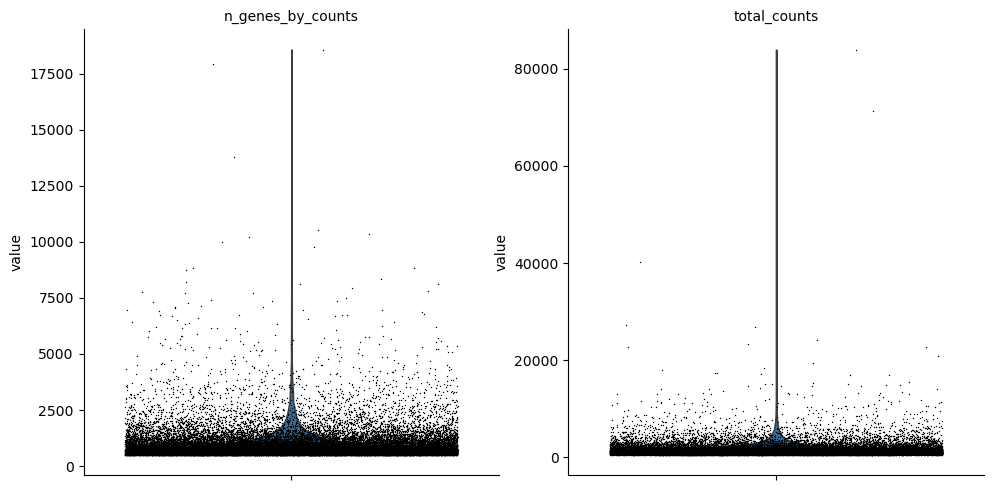

In [21]:
sc.pl.violin(
    full_concatenated_adata,
    [
        "n_genes_by_counts",
        "total_counts",
    ],
    jitter=0.4,
    multi_panel=True,
)

In [23]:
sc.pp.filter_cells(
    full_concatenated_adata,
    min_genes=500,
)
sc.pp.filter_genes(full_concatenated_adata, min_cells=5)

In [24]:
full_concatenated_adata

AnnData object with n_obs × n_vars = 30120 × 40379
    obs: 'batch', 'n_genes_by_counts', 'log1p_n_genes_by_counts', 'total_counts', 'log1p_total_counts', 'pct_counts_in_top_50_genes', 'pct_counts_in_top_100_genes', 'pct_counts_in_top_200_genes', 'pct_counts_in_top_500_genes', 'n_genes'
    var: 'n_cells_by_counts', 'mean_counts', 'log1p_mean_counts', 'pct_dropout_by_counts', 'total_counts', 'log1p_total_counts', 'n_cells'

In [25]:
sc.pp.normalize_total(full_concatenated_adata, target_sum=1e4)
sc.pp.log1p(full_concatenated_adata)

In [26]:
full_concatenated_adata

AnnData object with n_obs × n_vars = 30120 × 40379
    obs: 'batch', 'n_genes_by_counts', 'log1p_n_genes_by_counts', 'total_counts', 'log1p_total_counts', 'pct_counts_in_top_50_genes', 'pct_counts_in_top_100_genes', 'pct_counts_in_top_200_genes', 'pct_counts_in_top_500_genes', 'n_genes'
    var: 'n_cells_by_counts', 'mean_counts', 'log1p_mean_counts', 'pct_dropout_by_counts', 'total_counts', 'log1p_total_counts', 'n_cells'
    uns: 'log1p'

In [27]:
sc.pp.highly_variable_genes(
    full_concatenated_adata, n_top_genes=2000, batch_key="batch"
)

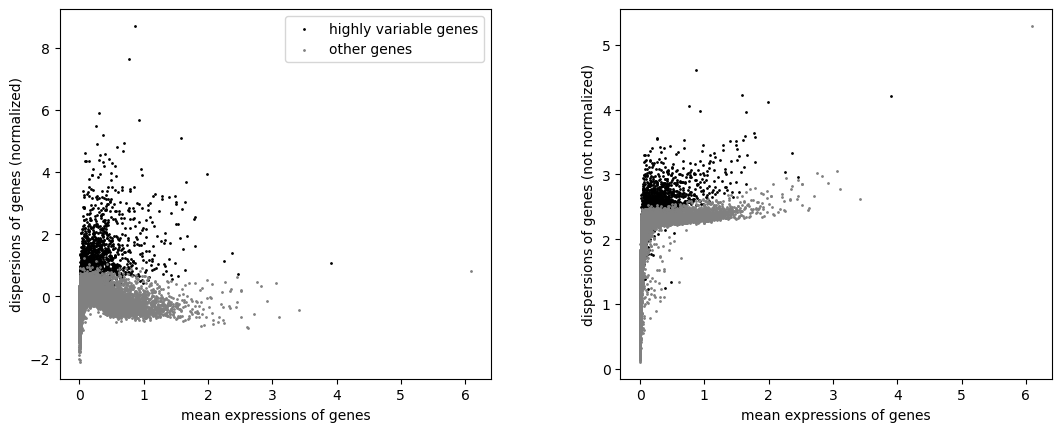

In [28]:
sc.pl.highly_variable_genes(full_concatenated_adata)

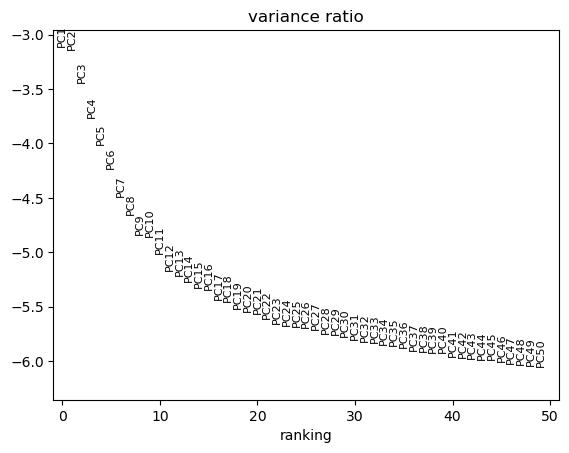

In [29]:
sc.tl.pca(full_concatenated_adata)
sc.pl.pca_variance_ratio(full_concatenated_adata, n_pcs=50, log=True)

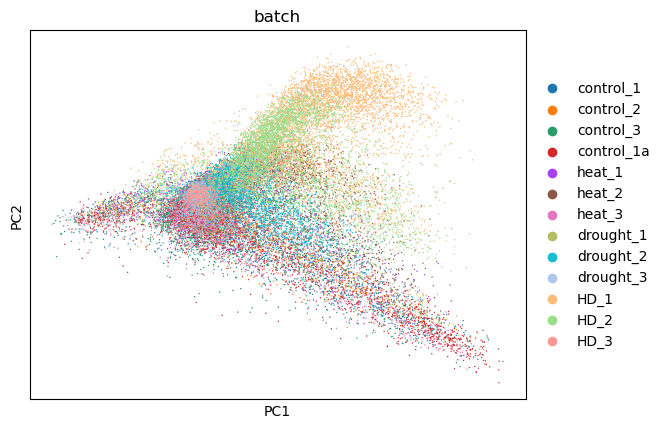

In [30]:
sc.pl.pca(
    full_concatenated_adata,
    color=["batch"],
)

In [31]:
sc.pp.neighbors(full_concatenated_adata)

In [32]:
sc.tl.umap(full_concatenated_adata)

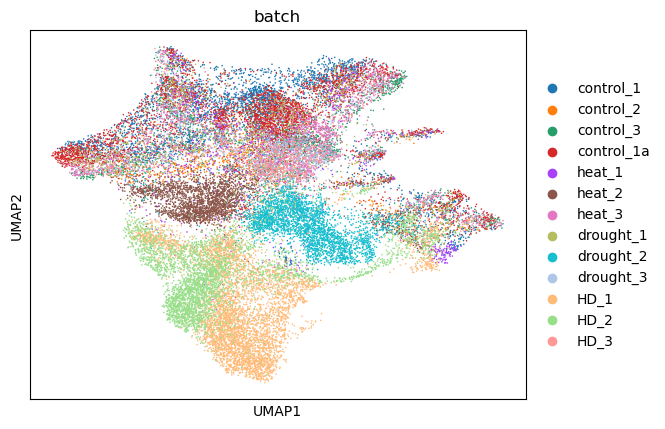

In [33]:
sc.pl.umap(
    full_concatenated_adata,
    color="batch",
    size=5,
)

In [39]:
sc.tl.leiden(full_concatenated_adata, flavor="igraph", resolution=0.8)

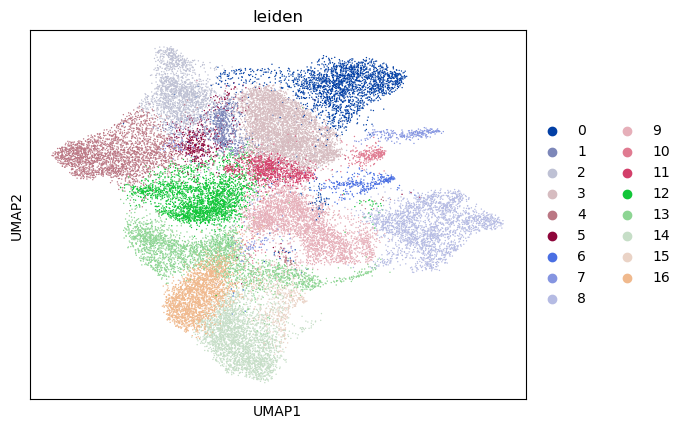

In [40]:
sc.pl.umap(full_concatenated_adata, color=["leiden"])

In [36]:
labeled_data = sc.read_h5ad("/Users/michael/Data/Soybean_data/adata_rna.h5ad")
labeled_data

AnnData object with n_obs × n_vars = 30467 × 36042
    obs: 'orig.ident', 'nCount_RNA', 'nFeature_RNA', 'sample', 'pctCP', 'pctMT', 'nUMI_raw', 'nCount_SCT', 'nFeature_SCT', 'SCT_snn_res.0.3', 'SCT_snn_res.0.4', 'SCT_snn_res.0.5', 'SCT_snn_res.0.6', 'SCT_snn_res.0.7', 'SCT_snn_res.0.8', 'SCT_snn_res.0.9', 'SCT_snn_res.1', 'seurat_clusters', 'treatment', 'libraries', 'replicate', 'source_rds', 'integrated_snn_res.0.5', 'celltype_call', 'cluster_annot'
    var: 'highly_variable', 'in_integrated'
    uns: 'neighbors', 'pca', 'pca_loadings', 'source'
    obsm: 'X_pca', 'X_umap'
    layers: 'counts'
    obsp: 'connectivities', 'distances'

In [38]:
labeled_data.obs["cluster_annot"]

leaf_control_rep1_AATCCCTGTGATGGCT-1                      Epidermal-4
leaf_control_rep1_TTTACGCGTGGAAACG-1    Vascular/Phloem parenchyma-11
leaf_control_rep1_GAACACAAGTTACCGG-1                   Guard cells-12
leaf_control_rep1_TCATTGCGTGAGCAAG-1                 Bundle sheath-10
leaf_control_rep1_CTCATTAGTTAAGCCA-1                      Mesophyll-2
                                                    ...              
leaf_Heat_rep3_CAGGATGCATGTCGCG-1                         Mesophyll-8
leaf_Heat_rep3_CCTATAGCATGTCGCG-1                         Mesophyll-0
leaf_Heat_rep3_AGGTCCGGTGTCACGG-1                         Mesophyll-0
leaf_Heat_rep3_TTCATTCAGCTAATTG-1                      Guard cells-12
leaf_Heat_rep3_ATGATGGAGCAGGTGG-1                         Mesophyll-0
Name: cluster_annot, Length: 30467, dtype: category
Categories (17, object): ['Epidermal-4', 'Epidermal/Pavement-9', 'Guard cells-12', 'Hydathode cells-15', ..., 'Bundle sheath-3', 'Vascular/Phloem parenchyma-11', 'Companion cells

,batch,n_genes_by_counts,log1p_n_genes_by_counts,total_counts,log1p_total_counts,pct_counts_in_top_50_genes,pct_counts_in_top_100_genes,pct_counts_in_top_200_genes,pct_counts_in_top_500_genes,n_genes,leiden
AAACAGCCATGTCGCG-1-control_1,control_1,590,6.381816,820.0,6.710523,32.439024,40.243902,52.439024,89.024390,589,0
AAACATGCATACTCCT-1-control_1,control_1,1658,7.413970,2967.0,7.995644,36.366700,41.152679,47.893495,60.970677,1658,1
AAACCGAAGACCATAC-1-control_1,control_1,736,6.602588,1051.0,6.958448,30.922931,39.486204,49.000951,77.545195,736,2
AAACCGCGTTCAAGAT-1-control_1,control_1,549,6.309918,877.0,6.777647,40.022805,48.802737,60.205245,94.412771,549,3
AAACCGGCAAACTGCC-1-control_1,control_1,1606,7.382124,2623.0,7.872455,27.373237,33.739992,42.012962,57.834541,1606,0
...,...,...,...,...,...,...,...,...,...,...,...
TTTGCGACATAGCAGG-1-HD_3,HD_3,661,6.495266,780.0,6.660575,16.410256,28.076923,40.897436,79.358974,661,11
TTTGCGACATTGCAGC-1-HD_3,HD_3,787,6.669498,910.0,6.814543,14.395604,24.505495,35.494505,68.461538,786,3
TTTGCGGAGGCGAAAC-1-HD_3,HD_3,784,6.665684,899.0,6.802395,15.016685,23.915462,35.038932,68.409344,784,3
TTTGTGTTCCGCAAGC-1-HD_3,HD_3,845,6.740519,1023.0,6.931472,16.324536,26.099707,36.950147,66.275660,844,4


28298 cells shared (30120 reclustered, 30467 annotated)


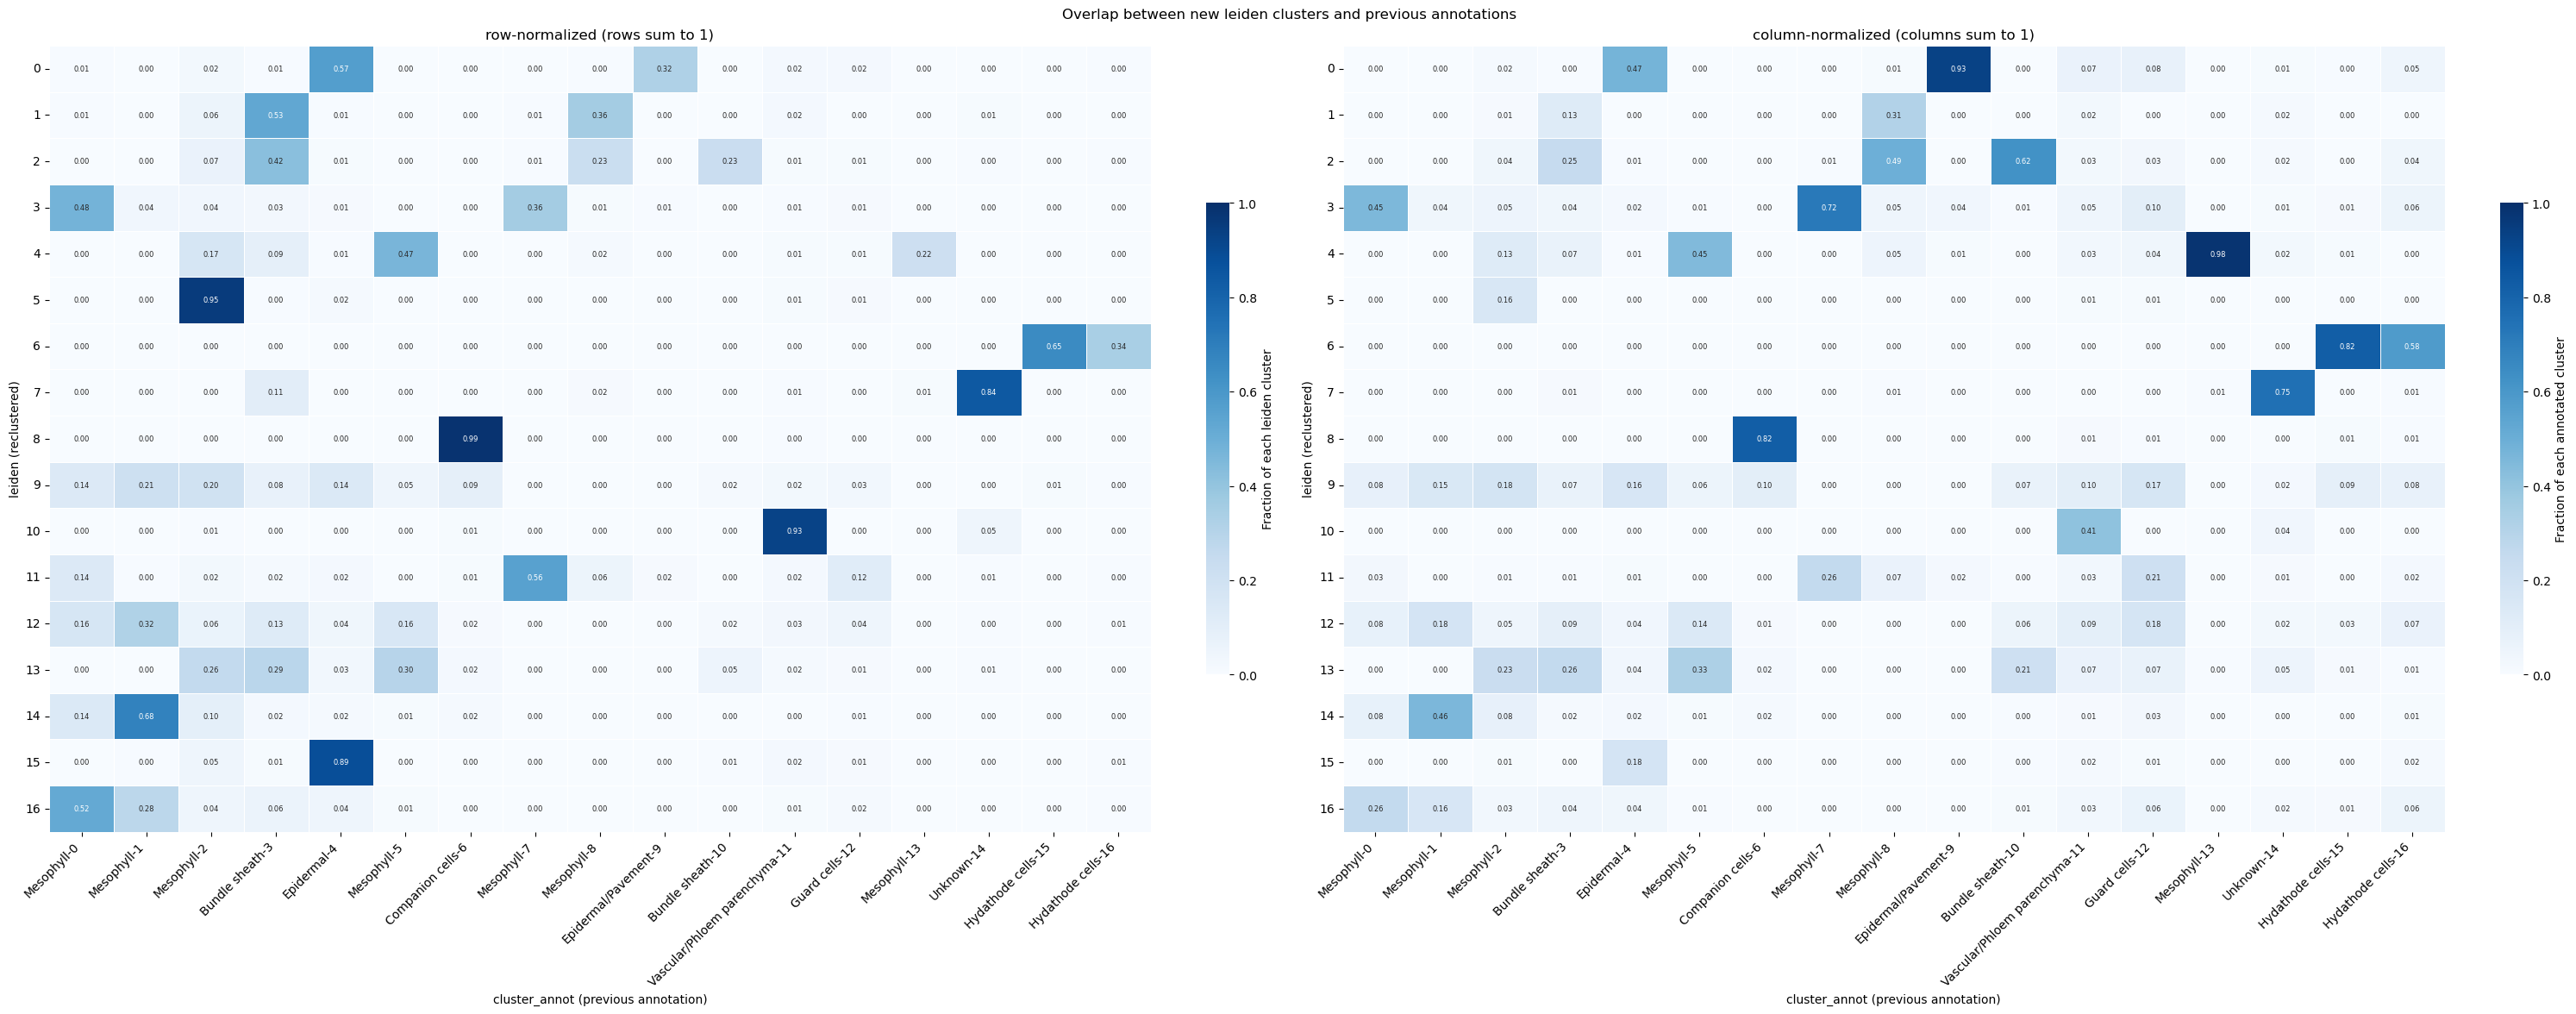

In [42]:
# Compare the new leiden clusters to the previously annotated clusters.
# Batch keys used in the concatenation map onto the sample names of the annotated object.
batch_to_sample = {
    "control_1": "leaf_control_rep1",
    "control_1a": "leaf_control_rep1A",
    "control_2": "leaf_control_rep2",
    "control_3": "leaf_control_rep3",
    "heat_1": "leaf_Heat_rep1",
    "heat_2": "leaf_Heat_rep2",
    "heat_3": "leaf_Heat_rep3",
    "drought_1": "leaf_drought_rep1",
    "drought_2": "leaf_drought_rep2",
    "drought_3": "leaf_drought_rep3",
    "HD_1": "leaf_HD_rep1",
    "HD_2": "leaf_HD_rep2",
    "HD_3": "leaf_HD_rep3",
}

# "AAACAGCCATGTCGCG-1-control_1" -> "leaf_control_rep1_AAACAGCCATGTCGCG-1"
new_clusters = pd.Series(
    full_concatenated_adata.obs["leiden"].astype(str).values,
    index=[
        f"{batch_to_sample[batch]}_{name.rsplit('-', 1)[0]}"
        for name, batch in zip(
            full_concatenated_adata.obs_names,
            full_concatenated_adata.obs["batch"].astype(str),
        )
    ],
    name="leiden",
)
old_clusters = pd.Series(
    labeled_data.obs["cluster_annot"].astype(str).values,
    index=labeled_data.obs_names,
    name="cluster_annot",
)

shared = pd.concat([new_clusters, old_clusters], axis=1, join="inner")
print(
    f"{len(shared)} cells shared "
    f"({full_concatenated_adata.n_obs} reclustered, {labeled_data.n_obs} annotated)"
)

overlap_counts = pd.crosstab(shared["leiden"], shared["cluster_annot"])
overlap_counts = overlap_counts.loc[
    sorted(overlap_counts.index, key=int),
    sorted(overlap_counts.columns, key=lambda c: int(c.rsplit("-", 1)[1])),
]

# Normalize both ways so cluster size differences do not drive the colors
frac_of_leiden = overlap_counts.div(overlap_counts.sum(axis=1), axis=0)
frac_of_annot = overlap_counts.div(overlap_counts.sum(axis=0), axis=1)

n_rows, n_cols = overlap_counts.shape
fig, axes = plt.subplots(
    1, 2, figsize=(2 * (0.7 * n_cols + 3), 0.45 * n_rows + 4), constrained_layout=True
)
panels = [
    (
        frac_of_leiden,
        "Fraction of each leiden cluster",
        "row-normalized (rows sum to 1)",
    ),
    (
        frac_of_annot,
        "Fraction of each annotated cluster",
        "column-normalized (columns sum to 1)",
    ),
]
for ax, (matrix, cbar_label, title) in zip(axes, panels):
    sns.heatmap(
        matrix,
        ax=ax,
        cmap="Blues",
        vmin=0,
        vmax=1,
        annot=True,
        fmt=".2f",
        annot_kws={"size": 6},
        linewidths=0.5,
        linecolor="white",
        cbar_kws={"label": cbar_label, "shrink": 0.6},
    )
    ax.set_title(title)
    ax.set_xlabel("cluster_annot (previous annotation)")
    ax.set_ylabel("leiden (reclustered)")
    ax.set_xticklabels(ax.get_xticklabels(), rotation=45, ha="right")
    ax.set_yticklabels(ax.get_yticklabels(), rotation=0)

fig.suptitle("Overlap between new leiden clusters and previous annotations")
plt.show()

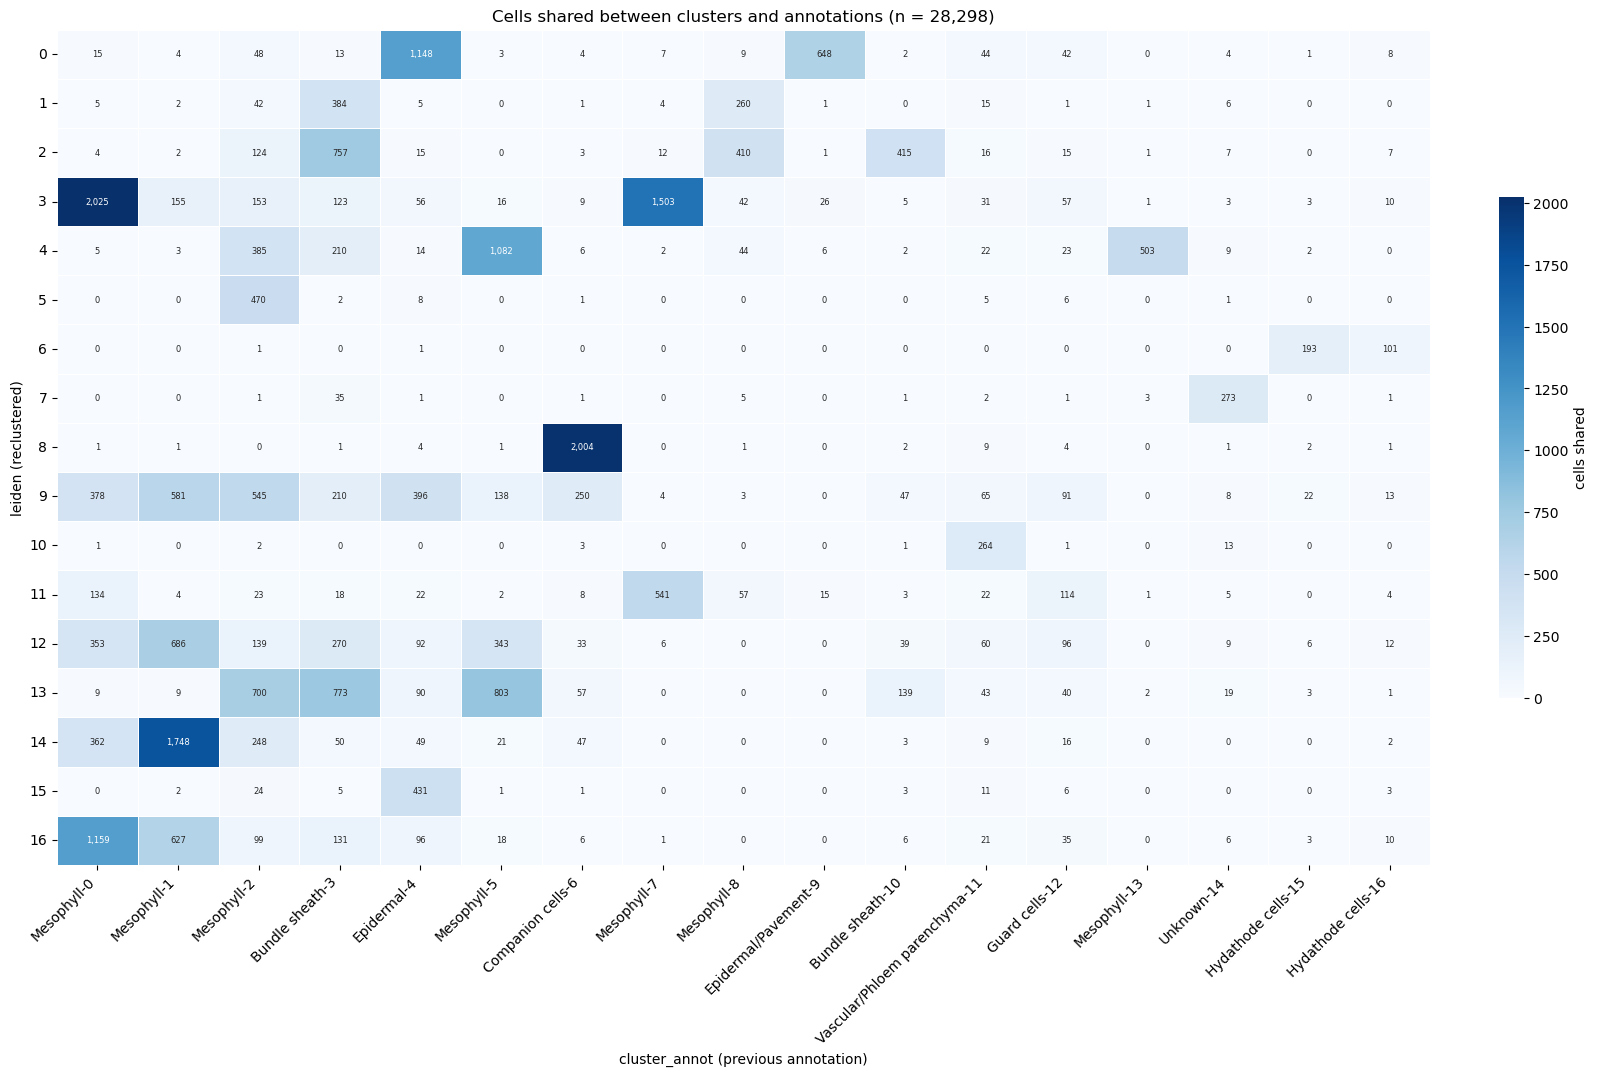

leiden
0     2000
1      727
2     1789
3     4218
4     2318
5      493
6      296
7      324
8     2032
9     2751
10     285
11     973
12    2144
13    2688
14    2555
15     487
16    2218

cluster_annot
Mesophyll-0                      4451
Mesophyll-1                      3824
Mesophyll-2                      3004
Bundle sheath-3                  2982
Epidermal-4                      2428
Mesophyll-5                      2428
Companion cells-6                2434
Mesophyll-7                      2080
Mesophyll-8                       831
Epidermal/Pavement-9              697
Bundle sheath-10                  668
Vascular/Phloem parenchyma-11     639
Guard cells-12                    548
Mesophyll-13                      512
Unknown-14                        364
Hydathode cells-15                235
Hydathode cells-16                173


In [43]:
# Same overlap, unnormalized: total number of cells shared by each pair
fig, ax = plt.subplots(
    figsize=(0.7 * n_cols + 4, 0.45 * n_rows + 3), constrained_layout=True
)
sns.heatmap(
    overlap_counts,
    ax=ax,
    cmap="Blues",
    vmin=0,
    annot=True,
    fmt=",d",
    annot_kws={"size": 6},
    linewidths=0.5,
    linecolor="white",
    cbar_kws={"label": "cells shared", "shrink": 0.6},
)
ax.set_title(f"Cells shared between clusters and annotations (n = {len(shared):,})")
ax.set_xlabel("cluster_annot (previous annotation)")
ax.set_ylabel("leiden (reclustered)")
ax.set_xticklabels(ax.get_xticklabels(), rotation=45, ha="right")
ax.set_yticklabels(ax.get_yticklabels(), rotation=0)
plt.show()

# Cluster sizes behind the heatmap
print(overlap_counts.sum(axis=1).rename("cells per leiden cluster").to_string())
print()
print(overlap_counts.sum(axis=0).rename("cells per annotated cluster").to_string())